# Systematic evaluation of the pipeline - **GOOD** & **BAD** Dialogs

## Load data & Setup

In [ ]:
# Mount Google Drive and set paths

from google.colab import drive
import os
import json
import pandas as pd
import re

# mount Drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
OUTPUT_DIR = "/content/drive/MyDrive/Masterarbeit/Dialoge/Evaluation_Outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
# base directory
SAVE_DIR = "/content/drive/MyDrive/Masterarbeit/Dialoge"

# Paths to JSON files (GOOD & BAD dialogs)
good_path = os.path.join(SAVE_DIR, "all_dialogs_generated.json")
bad_path = os.path.join(SAVE_DIR, "all_bad_dialogs_generated.json")

print("GOOD JSON:", good_path)
print("BAD JSON :", bad_path)

# Check availability
assert os.path.exists(good_path), f"GOOD JSON not found at {good_path}"
assert os.path.exists(bad_path), f"BAD JSON not found at {bad_path}"

GOOD JSON: /content/drive/MyDrive/Masterarbeit/Dialoge/all_dialogs_generated.json
BAD JSON : /content/drive/MyDrive/Masterarbeit/Dialoge/all_bad_dialogs_generated.json


In [ ]:
# load JSONs with good and bad dialogs

def load_good_bad_dialogs(good_path: str, bad_path: str) -> pd.DataFrame:
  """
  Loads GOOD and BAD dialogues from the two JSON files and
  returns a joint DataFrame.
  """
  with open(good_path, "r", encoding="utf-8") as f:
    good_data = json.load(f)
  with open(bad_path, "r", encoding="utf-8") as f:
    bad_data = json.load(f)

  records = []

  # GOOD
  for entry in good_data:
      records.append({
          "dialog_id": entry.get("dialog_id", ""),
          "condition": "good",
          "recipe": entry.get("recipe", ""),
          "discussion": entry.get("discussion", "")
          })

    # BAD
  for entry in bad_data:
      records.append({
          "dialog_id": entry.get("dialog_id", ""),
          "condition": "bad",
          "recipe": entry.get("recipe", ""),
          "discussion": entry.get("discussion_bad", "")
          })

  return pd.DataFrame(records)

df_all = load_good_bad_dialogs(good_path, bad_path)
print(f"Loaded {len(df_all)} dialogs (GOOD + BAD)")
display(df_all.head())

Loaded 80 dialogs (GOOD + BAD)


,dialog_id,condition,recipe,discussion
0,R000_G,good,Moong Dal,Fat: Moong Dal has low fat content.\nCarb: Mos...
1,R001_G,good,Bourbon Wieners,Fat: Bourbon Wieners have a notable fat conten...
2,R003_G,good,Cobb Salad Ham Roll-ups,Fat: The fat content seems relatively high due...
3,R004_G,good,Grain-Free Apple Cinnamon Dutch Babies,Fat: This recipe has a moderate fat content fr...
4,R005_G,good,Best Ever Muffins,Fat: The fat content seems relatively low in t...


## Structural analysis

In [ ]:
def analyze_dialog_structure(row):
    """
    Checks basic structural properties of a dialog:
    - Number of lines
    - Fat/Carb alternation
    - Other roles
    - Length, number of questions
    - Error markers, user/system tokens
    """
    text = row["discussion"] or ""
    # Lines without blank lines
    lines = [l.strip() for l in text.split("\n") if l.strip()]

    num_lines = len(lines)
    # Role = everything before the first ":" (or "")
    starts = [l.split(":", 1)[0] if ":" in l else "" for l in lines]

    # Alternation-Check: Fat, Carb, Fat, Carb, ...
    alt_ok = True
    if num_lines >= 2:
        for i, role in enumerate(starts):
            expected = "Fat" if i % 2 == 0 else "Carb"
            if role != expected:
                alt_ok = False
                break
    else:
        alt_ok = False

    # Number of Turn per role
    fat_turns = sum(1 for s in starts if s == "Fat")
    carb_turns = sum(1 for s in starts if s == "Carb")

    # other roles (e.g. "User", "System")
    other_roles = [s for s in starts if s not in ("Fat", "Carb", "")]

    # Text statistics
    text_len = len(text)
    num_q = text.count("?")
    num_error = text.count("[ERROR")

    return {
        "num_lines": num_lines,
        "alt_ok": alt_ok,
        "fat_turns": fat_turns,
        "carb_turns": carb_turns,
        "other_roles": ",".join(sorted(set(other_roles))) if other_roles else "",
        "text_len": text_len,
        "num_questions": num_q,
        "has_error_marker": num_error > 0,
        "has_user_token": ("User:" in text) or ("System:" in text)
    }


qc_records = []
for i, row in df_all.iterrows():
    stats = analyze_dialog_structure(row)
    stats.update({
        "dialog_id": row["dialog_id"],
        "condition": row["condition"],
        "recipe": row["recipe"]
    })
    qc_records.append(stats)

df_qc = pd.DataFrame(qc_records)
print("QC overview (first lines):")
display(df_qc.head())

QC overview (first lines):


,num_lines,alt_ok,fat_turns,carb_turns,other_roles,text_len,num_questions,has_error_marker,has_user_token,dialog_id,condition,recipe
0,20,True,10,10,,1111,0,False,False,R000_G,good,Moong Dal
1,20,True,10,10,,1660,0,False,False,R001_G,good,Bourbon Wieners
2,20,True,10,10,,1854,2,False,False,R003_G,good,Cobb Salad Ham Roll-ups
3,20,True,10,10,,1638,2,False,False,R004_G,good,Grain-Free Apple Cinnamon Dutch Babies
4,20,True,10,10,,1539,3,False,False,R005_G,good,Best Ever Muffins


In [ ]:
df_qc.to_csv('/content/drive/MyDrive/Masterarbeit/Dialoge/Evaluation_Outputs/automated_structure_check.csv', index=False)

## QC-Filtering & Export

In [ ]:
# Filtering problem cases

# Criteria for "conspicuous"
problematic = df_qc[
    (df_qc["num_lines"] != 20) |      # not exactly 20 turns
    (df_qc["alt_ok"] == False) |      # wrong order
    (df_qc["has_error_marker"]) |     # Error-Markers
    (df_qc["has_user_token"]) |       # User/System-Token
    (df_qc["text_len"] < 300)         # very short dialogs
]

print(f"Conspicuous dialogues: {len(problematic)}")
display(problematic.sort_values(["condition", "dialog_id"]).head(50))

# Save as CSV for later review
problematic.to_csv("dialog_qc_flags.csv", index=False)
print("Saved QC flags to dialog_qc_flags.csv")

Conspicuous dialogues: 0


,num_lines,alt_ok,fat_turns,carb_turns,other_roles,text_len,num_questions,has_error_marker,has_user_token,dialog_id,condition,recipe


Saved QC flags to dialog_qc_flags.csv


## JSON validation with error handling

Note: from here onwards, the full text of Chapter 7.1 of the master’s thesis

In [ ]:
import json

def validate_json_files(paths: list[str]) -> dict:
    results = {}
    for path in paths:
        try:
            with open(path, "r", encoding="utf-8") as f:
                json.load(f)
            results[path] = "valid"
        except json.JSONDecodeError as e:
            results[path] = f"INVALID: {e}"
    return results

validation_report = validate_json_files([good_path, bad_path])
for path, status in validation_report.items():
    print(f"{os.path.basename(path)}: {status}")

all_dialogs_generated.json: valid
all_bad_dialogs_generated.json: valid


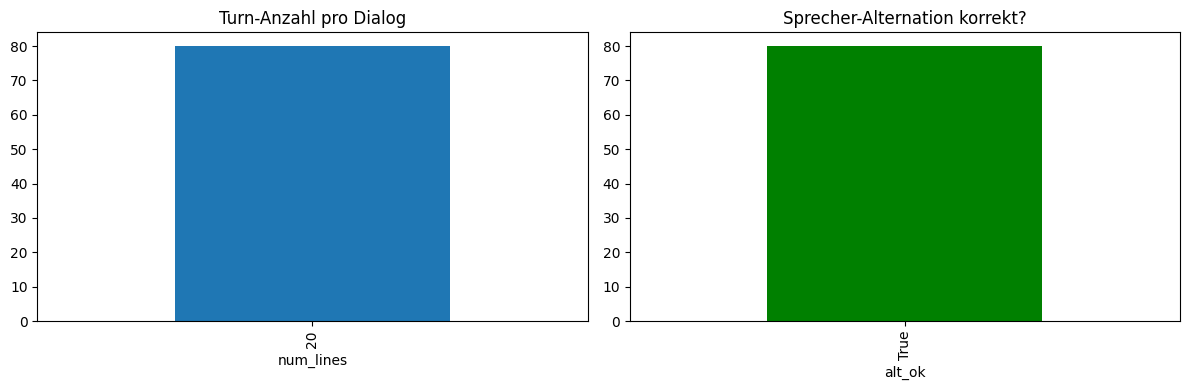

In [ ]:
# Visualisation of structural indicators

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Distribution of the number of turns
df_qc["num_lines"].value_counts().plot(kind="bar", ax=axes[0], title="Turn-Anzahl pro Dialog")
# Alt-OK Rate
df_qc["alt_ok"].value_counts().plot(kind="bar", ax=axes[1],
    title="Sprecher-Alternation korrekt?", color=["green","red"])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "structure_check_overview.png"), dpi=150)
plt.show()

## Role coherence - manual review data

In [ ]:
# Values known from the manual review process (two generation runs)
TOTAL_INITIAL_DIALOGS = 80   # First generation run (40 good + 40 bad)
TOTAL_REGEN_DIALOGS   = 11   # Of these, sorted out and regenerated (2nd run)
FINAL_CORPUS          = 80   # Final corpus after QA (11 regenerated, none excluded again)

# Breakdown by R-criterion (not a single R6 case!)
R4_TOO_SHORT_REPETITIVE  = 4   # Turns too short / repetitive
R5_MEASUREMENT_ARTIFACT  = 7   # Undesirable measurement formats (%, g, calories)
R6_CONSTRAINT_VIOLATION  = 0   # Role violations → NO cases occurred

exclusion_rate = TOTAL_REGEN_DIALOGS / TOTAL_INITIAL_DIALOGS * 100

print(f"Erster Generierungslauf:       {TOTAL_INITIAL_DIALOGS} Dialoge")
print(f"Davon aussortiert:             {TOTAL_REGEN_DIALOGS} ({exclusion_rate:.1f}%)")
print(f"  → R4_TOO_SHORT_REPETITIVE:   {R4_TOO_SHORT_REPETITIVE}x")
print(f"  → R5_MEASUREMENT_ARTIFACT:   {R5_MEASUREMENT_ARTIFACT}x")
print(f"  → R6_CONSTRAINT_VIOLATION:   {R6_CONSTRAINT_VIOLATION}x  ← Rollenstabilität bestätigt")
print(f"Zweiter Generierungslauf:      {TOTAL_REGEN_DIALOGS} Dialoge (alle akzeptiert)")
print(f"Finaler Korpus:                {FINAL_CORPUS} Dialoge")

Erster Generierungslauf:       80 Dialoge
Davon aussortiert:             11 (13.8%)
  → R4_TOO_SHORT_REPETITIVE:   4x
  → R5_MEASUREMENT_ARTIFACT:   7x
  → R6_CONSTRAINT_VIOLATION:   0x  ← Rollenstabilität bestätigt
Zweiter Generierungslauf:      11 Dialoge (alle akzeptiert)
Finaler Korpus:                80 Dialoge


## Task focus via BERTopic

In [ ]:
# Installation (once)
!pip install bertopic sentence-transformers

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import re

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


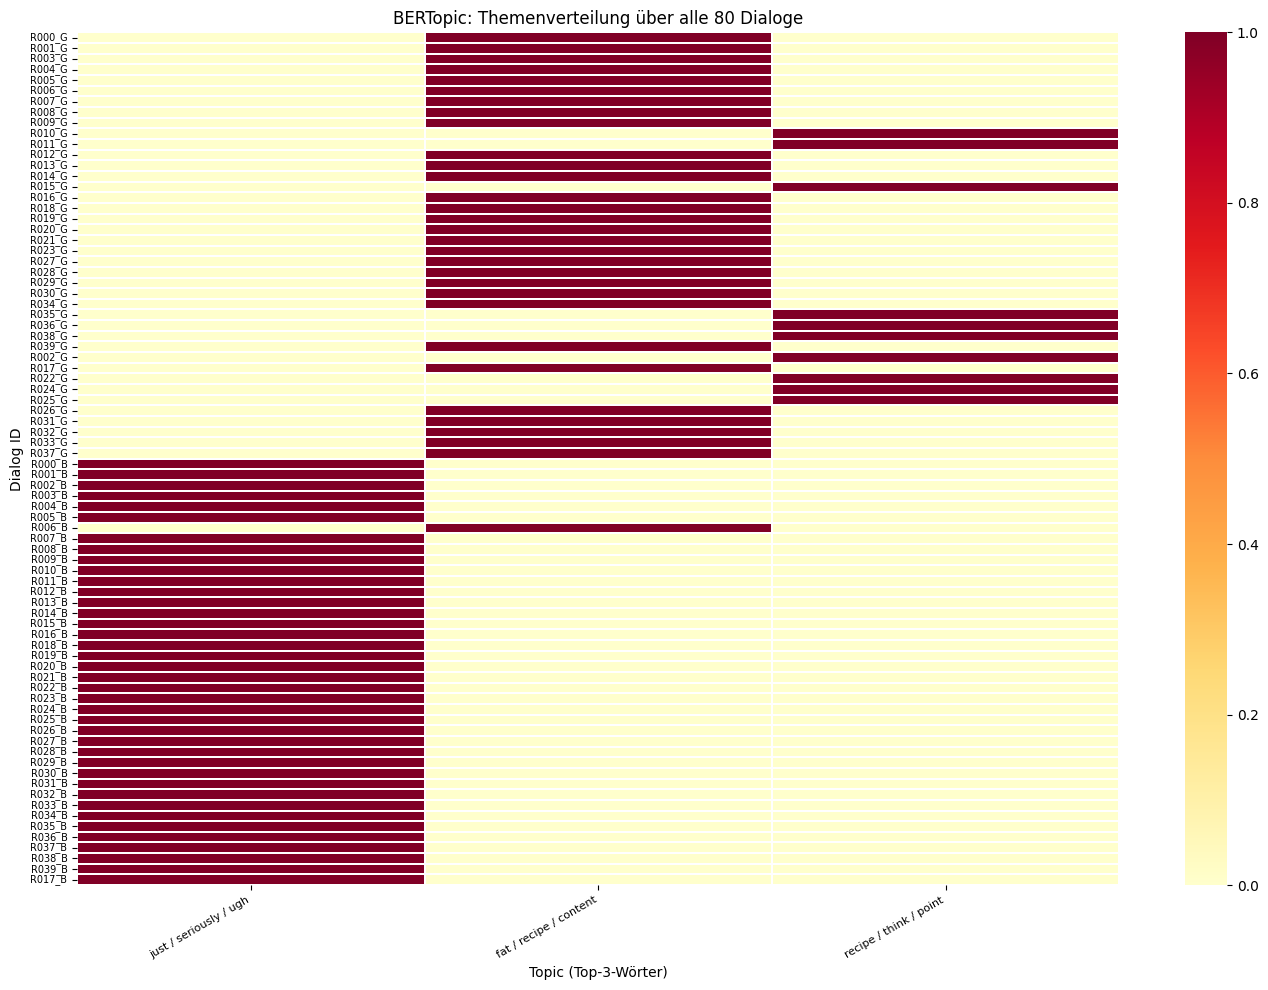


Gefundene Topics:
  Topic 0: just / seriously / ugh
  Topic 1: fat / recipe / content
  Topic 2: recipe / think / point


In [ ]:
# Remove speaker prefixes before topic analysis
def strip_speaker_prefixes(text: str) -> str:
    """Removes "Fat: " and "Carb: " prefixes from all turns."""
    text = re.sub(r"^(Fat|Carb):\s*", "", text, flags=re.MULTILINE)
    return text.strip()

docs_clean = [strip_speaker_prefixes(d) for d in df_all["discussion"].tolist()]
dialog_ids = df_all["dialog_id"].tolist()

# Model with English-language embedding
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# K-means instead of HDBSCAN, better for small corpora (n=80)
cluster_model = KMeans(n_clusters=6, random_state=42)

# Remove stop words + domain-specific common words
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer,
    nr_topics=3,
    calculate_probabilities=False
)

topics, _ = topic_model.fit_transform(docs_clean)  # ← docs_clean instead of docs

# Probabilities as a one-hot matrix
n_topics = len(set(topics))
probs = np.zeros((len(topics), n_topics))
for idx, t in enumerate(topics):
    if t >= 0:
        probs[idx, t] = 1.0

# Generate topic labels from the top 3 words per topic
topic_labels = {}
for i in range(n_topics):
    topic_words = topic_model.get_topic(i)
    if topic_words:
        topic_labels[i] = " / ".join([w for w, _ in topic_words[:3]])
    else:
        topic_labels[i] = f"Topic_{i}"

# Topic distribution as a DataFrame
topic_df = pd.DataFrame(
    probs,
    index=dialog_ids,
    columns=[topic_labels.get(i, f"Topic_{i}") for i in range(n_topics)]
)
topic_df["condition"] = df_all["condition"].values

# Heatmap of topic distribution
plt.figure(figsize=(14, 10))
sns.heatmap(
    topic_df.drop("condition", axis=1),
    cmap="YlOrRd",
    yticklabels=dialog_ids,
    xticklabels=True,
    linewidths=0.3,
    linecolor="white"
)
plt.title("BERTopic: Themenverteilung über alle 80 Dialoge")
plt.xlabel("Topic (Top-3-Wörter)")
plt.ylabel("Dialog ID")
plt.xticks(rotation=30, ha="right", fontsize=8)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "topic_heatmap.png"), dpi=150)
plt.show()

# Overview of topics for interpretation
print("\nGefundene Topics:")
for topic_id, label in topic_labels.items():
    print(f"  Topic {topic_id}: {label}")

In [ ]:
# Check: Topic distribution by condition
topic_df["topic"] = topics
print(topic_df.groupby(["condition", "topic"]).size().unstack(fill_value=0))

topic       0   1   2
condition            
bad        39   1   0
good        0  30  10


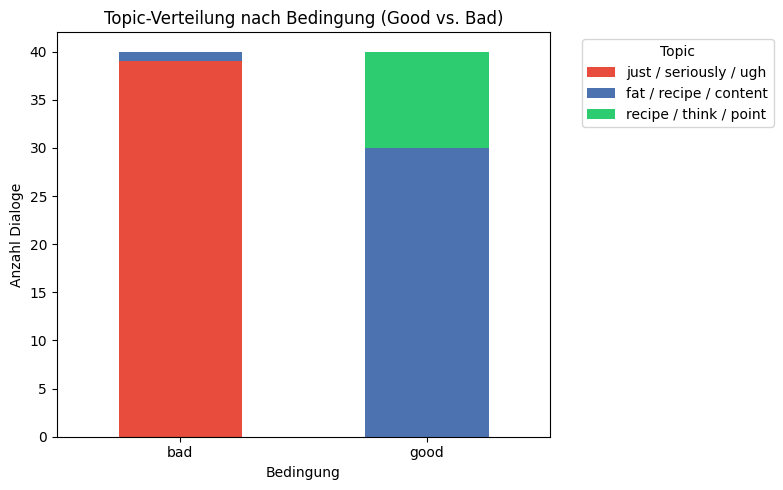


Topic-Verteilung nach Bedingung:
           just / seriously / ugh  fat / recipe / content  \
condition                                                   
bad                            39                       1   
good                            0                      30   

           recipe / think / point  
condition                          
bad                             0  
good                           10  


In [ ]:
# Stacked bar chart: Topic distribution by condition
topic_condition = topic_df.groupby(["condition", "topic"]).size().unstack(fill_value=0)
topic_condition.columns = [topic_labels[i] for i in topic_condition.columns]

topic_condition.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["#e74c3c", "#4C72B0", "#2ecc71"]
)
plt.title("Topic-Verteilung nach Bedingung (Good vs. Bad)")
plt.xlabel("Bedingung")
plt.ylabel("Anzahl Dialoge")
plt.xticks(rotation=0)
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "topic_distribution_by_condition.png"), dpi=150)
plt.show()

print("\nTopic-Verteilung nach Bedingung:")
print(topic_condition)

## Interaktionsdynamik

In [ ]:
# Share of Voice, Words per turn

def compute_word_counts_per_turn(row):
    """Returns a list of (role, word_count) tuples for each turn."""
    text = row["discussion"] or ""
    lines = [l.strip() for l in text.split("\n") if l.strip()]
    results = []
    for line in lines:
        if ":" in line:
            role, content = line.split(":", 1)
            word_count = len(content.strip().split())
            results.append({"role": role.strip(),
                             "word_count": word_count,
                             "dialog_id": row["dialog_id"],
                             "condition": row["condition"]})
    return results

# Collect all turns across all dialogs
all_turns = []
for _, row in df_all.iterrows():
    all_turns.extend(compute_word_counts_per_turn(row))

df_turns = pd.DataFrame(all_turns)

# Display descriptive statistics
print(df_turns.groupby(["condition", "role"])["word_count"].describe().round(2))

                count   mean   std  min   25%   50%   75%   max
condition role                                                 
bad       Carb  400.0   6.30  1.35  3.0   6.0   6.0   7.0  10.0
          Fat   400.0   6.18  1.37  3.0   5.0   6.0   7.0  11.0
good      Carb  400.0  11.66  2.68  6.0  10.0  12.0  13.0  22.0
          Fat   400.0  11.35  2.55  6.0  10.0  11.0  13.0  20.0


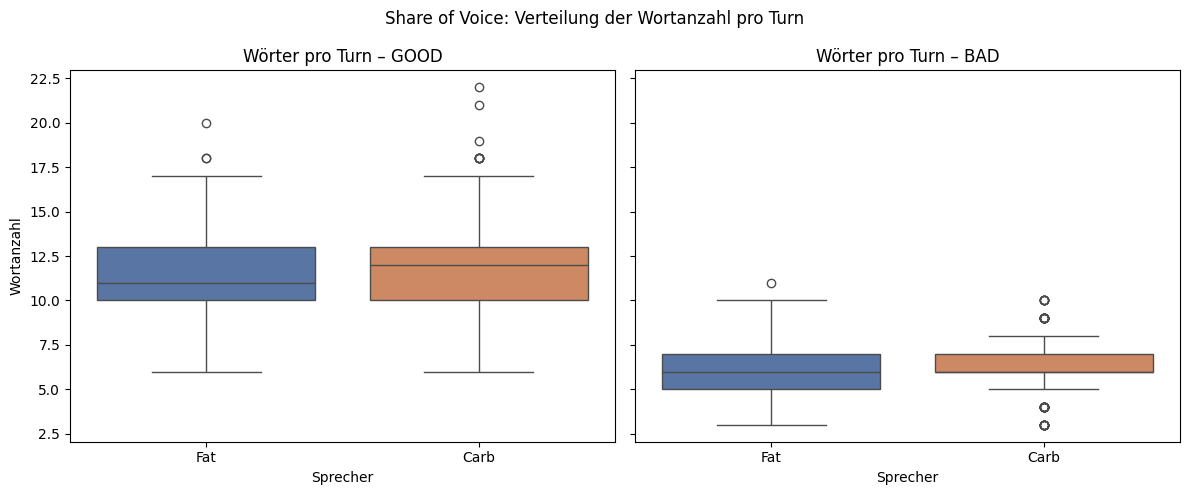

In [ ]:
# Box plot: Number of words per turn, broken down by role
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, cond in zip(axes, ["good", "bad"]):
    subset = df_turns[df_turns["condition"] == cond]
    sns.boxplot(data=subset, x="role", y="word_count", ax=ax,
                palette={"Fat": "#4C72B0", "Carb": "#DD8452"})
    ax.set_title(f"Wörter pro Turn – {cond.upper()}")
    ax.set_xlabel("Sprecher")
    ax.set_ylabel("Wortanzahl")
plt.suptitle("Share of Voice: Verteilung der Wortanzahl pro Turn")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "share_of_voice_boxplot.png"), dpi=150)
plt.show()

,Marker,Mean (Good),Mean (Bad),U-Statistik,p-Wert,Signifikant
0,positive_feedback,11.35,0.00,1600.0,0.0000,***
1,conflict,12.50,32.33,107.0,0.0000,***
2,justification,0.57,0.00,920.0,0.0118,*


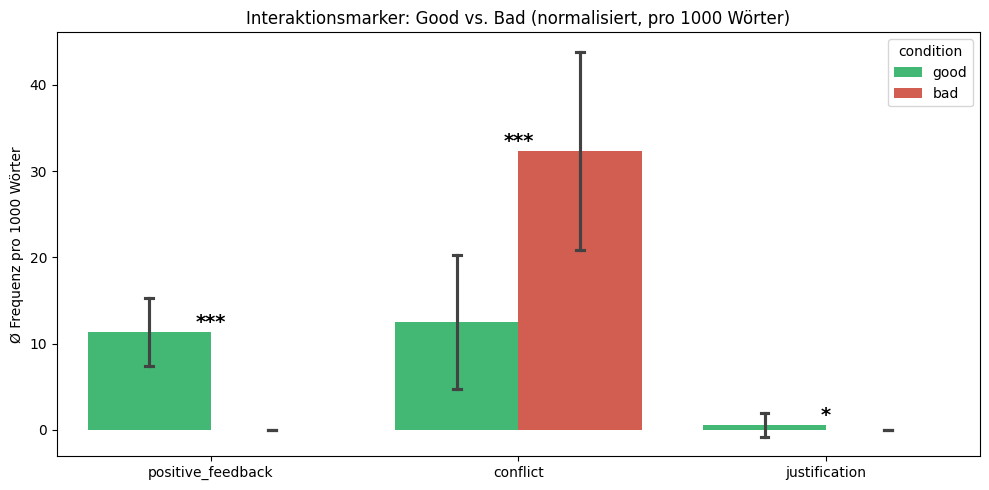

In [ ]:
# Dictionary-based interaction marker analysis with statistical testing

from scipy import stats
import numpy as np

# Define dictionaries (English, as all dialogues are in English)
MARKERS = {
    "positive_feedback": ["great idea", "i agree", "excellent", "good point",
                          "i appreciate", "that's helpful", "well said"],
    "conflict":          ["but", "however", "wrong", "no,", "disagree",
                          "that's not", "i don't think"],
    "justification":     ["because", "since", "therefore", "thus", "as a result",
                          "which means", "due to"]
}

def count_markers_normalized(text: str, marker_list: list[str]) -> float:
    """Normalised frequency: number of hits per 1,000 words."""
    text_lower = text.lower()
    total_words = len(text_lower.split())
    if total_words == 0:
        return 0.0
    count = sum(text_lower.count(m) for m in marker_list)
    return count / total_words * 1000

# Calculate frequencies
for marker_name, marker_list in MARKERS.items():
    df_all[f"freq_{marker_name}"] = df_all["discussion"].apply(
        lambda t: count_markers_normalized(t, marker_list)
    )

# Statistical comparison of Good vs. Bad (Mann-Whitney U test, as normal distribution is not assumed)
good_dialogs = df_all[df_all["condition"] == "good"]
bad_dialogs  = df_all[df_all["condition"] == "bad"]

results_table = []
for marker_name in MARKERS:
    col = f"freq_{marker_name}"
    stat, p = stats.mannwhitneyu(good_dialogs[col], bad_dialogs[col],
                                  alternative="two-sided")
    results_table.append({
        "Marker":         marker_name,
        "Mean (Good)":    round(good_dialogs[col].mean(), 2),
        "Mean (Bad)":     round(bad_dialogs[col].mean(), 2),
        "U-Statistik":    round(stat, 1),
        "p-Wert":         round(p, 4),
        "Signifikant":    "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "n.s."
    })

df_results = pd.DataFrame(results_table)
display(df_results)
df_results.to_csv(os.path.join(OUTPUT_DIR, "marker_analysis_results.csv"), index=False)

# Grouped bar chart
df_melt = df_all.melt(
    id_vars="condition",
    value_vars=[f"freq_{m}" for m in MARKERS],
    var_name="Marker", value_name="Frequenz"
)
df_melt["Marker"] = df_melt["Marker"].str.replace("freq_", "")

plt.figure(figsize=(10, 5))
sns.barplot(data=df_melt, x="Marker", y="Frequenz", hue="condition",
            palette={"good": "#2ecc71", "bad": "#e74c3c"},
            errorbar="sd", capsize=0.05)
plt.title("Interaktionsmarker: Good vs. Bad (normalisiert, pro 1000 Wörter)")
plt.ylabel("Ø Frequenz pro 1000 Wörter")
plt.xlabel("")
# Add significance stars
for i, row in enumerate(results_table):
    if row["Signifikant"] != "n.s.":
        y_pos = max(good_dialogs[f"freq_{row['Marker']}"].mean(),
                    bad_dialogs[f"freq_{row['Marker']}"].mean()) + 0.5
        plt.text(i, y_pos, row["Signifikant"],
                 ha="center", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "marker_comparison_barplot.png"), dpi=150)
plt.show()

## Zusammenfassende Summary-Zelle

In [ ]:
# Summary

print("=" * 60)
print("  PIPELINE EVALUATION SUMMARY (5.3.4)")
print("=" * 60)

# Corpus Overview
print(f"\nKORPUS")
print(f"  Finaler Korpus:          {len(df_all)} Dialoge")
print(f"  → davon GOOD:            {(df_all.condition=='good').sum()}")
print(f"  → davon BAD:             {(df_all.condition=='bad').sum()}")

# Structural integrity
print(f"\n5.3.1 STRUKTURELLE INTEGRITÄT")
print(f"  Turn-Anzahl = 20:        {(df_qc.num_lines==20).mean()*100:.1f}%  "
      f"({(df_qc.num_lines==20).sum()}/{len(df_qc)} Dialoge)")
print(f"  Sprecher-Alternation OK: {df_qc.alt_ok.mean()*100:.1f}%  "
      f"({df_qc.alt_ok.sum()}/{len(df_qc)} Dialoge)")
n_valid_json = sum(1 for s in validation_report.values() if s == "valid")
print(f"  JSON valide:             {n_valid_json/len(validation_report)*100:.1f}%  "
      f"({n_valid_json}/{len(validation_report)} Dateien)")
print(f"  Auffällige Dialoge (QC): {len(problematic)}")

# Role coherence
print(f"\n5.3.2 ROLLENKOHÄRENZ")
print(f"  Erster Generierungslauf:      {TOTAL_INITIAL_DIALOGS} Dialoge")
print(f"  Aussortiert & neu generiert:  {TOTAL_REGEN_DIALOGS} ({exclusion_rate:.1f}%)")
print(f"    → R4 (zu kurz/repetitiv):   {R4_TOO_SHORT_REPETITIVE}x")
print(f"    → R5 (Messartefakt):        {R5_MEASUREMENT_ARTIFACT}x")
print(f"    → R6 (Rollenverletzung):    {R6_CONSTRAINT_VIOLATION}x  ← keine Rollenfehler")
print(f"  Zweiter Generierungslauf:     {TOTAL_REGEN_DIALOGS} Dialoge (alle akzeptiert)")
print(f"  Dritter Generierungslauf:     nicht nötig")
# BERTopic-results
tc = topic_df.groupby(["condition", "topic"]).size().unstack(fill_value=0)
print(f"\n  BERTopic – Topic-Verteilung nach Bedingung:")
print(f"  {'Topic':<10}", end="")
for i in range(n_topics):
    print(f"  {topic_labels[i]:<25}", end="")
print()
for cond in ["bad", "good"]:
    print(f"  {cond.upper():<10}", end="")
    for i in range(n_topics):
        val = tc.loc[cond, i] if i in tc.columns else 0
        print(f"  {val:<25}", end="")
    print()

# Dynamics of interaction
print(f"\n5.3.3 INTERAKTIONSDYNAMIK")

# Share of Voice
sov = df_turns.groupby(["condition", "role"])["word_count"].mean().round(2)
print(f"\n  Share of Voice (Ø Wörter/Turn):")
print(f"  {'':20} {'GOOD':>8} {'BAD':>8}")
for role in ["Fat", "Carb"]:
    g = sov.get(("good", role), 0)
    b = sov.get(("bad",  role), 0)
    print(f"  {role:<20} {g:>8.2f} {b:>8.2f}")

# Marker analysis
print(f"\n  Interaktionsmarker (normalisiert, pro 1000 Wörter):")
print(f"  {'Marker':<22} {'Mean Good':>10} {'Mean Bad':>10} {'p-Wert':>8} {'Sig':>5}")
print(f"  {'-'*57}")
for row in results_table:
    print(f"  {row['Marker']:<22} {row['Mean (Good)']:>10.2f} "
          f"{row['Mean (Bad)']:>10.2f} {row['p-Wert']:>8.4f} {row['Signifikant']:>5}")

print(f"\n{'=' * 60}")
print(f"  Alle strukturellen Kriterien: 100% erfüllt")
print(f"  Experimentelle Manipulation:  quantitativ bestätigt")
print(f"{'=' * 60}")

  PIPELINE EVALUATION SUMMARY (5.3.4)

KORPUS
  Finaler Korpus:          80 Dialoge
  → davon GOOD:            40
  → davon BAD:             40

5.3.1 STRUKTURELLE INTEGRITÄT
  Turn-Anzahl = 20:        100.0%  (80/80 Dialoge)
  Sprecher-Alternation OK: 100.0%  (80/80 Dialoge)
  JSON valide:             100.0%  (2/2 Dateien)
  Auffällige Dialoge (QC): 0

5.3.2 ROLLENKOHÄRENZ
  Erster Generierungslauf:      80 Dialoge
  Aussortiert & neu generiert:  11 (13.8%)
    → R4 (zu kurz/repetitiv):   4x
    → R5 (Messartefakt):        7x
    → R6 (Rollenverletzung):    0x  ← keine Rollenfehler
  Zweiter Generierungslauf:     11 Dialoge (alle akzeptiert)
  Dritter Generierungslauf:     nicht nötig

  BERTopic – Topic-Verteilung nach Bedingung:
  Topic       just / seriously / ugh     fat / recipe / content     recipe / think / point   
  BAD         39                         1                          0                        
  GOOD        0                          30                         10